# Nile Minima Dataset


Import libraries


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from hurst import compute_Hc

In [2]:
INPUT_FILE = "../../data/raw/SN_ms_tot_V2.0.csv"
OUTPUT_FILE = "../../data/preprocessed/total_sunspots.csv"

In [3]:
df = pd.read_csv(INPUT_FILE)

df = pd.read_csv(INPUT_FILE, sep=";", header=None)
series = df.iloc[:, 3].astype(float)

# Replace -1 sentinel with NaN
series = series.replace(-1.0, np.nan)

# Trim leading and trailing NaNs
first_valid = series.first_valid_index()
last_valid = series.last_valid_index()
series = series.loc[first_valid:last_valid]

# Interpolate any remaining interior NaNs
series = series.interpolate(method="linear")
output_df = series.to_frame()
output_df.to_csv(OUTPUT_FILE, index=False, header=["time_series"])

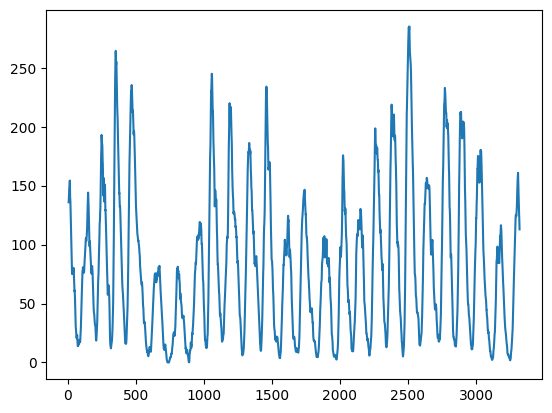

In [4]:
plt.figure()
plt.plot(series)

### ACF


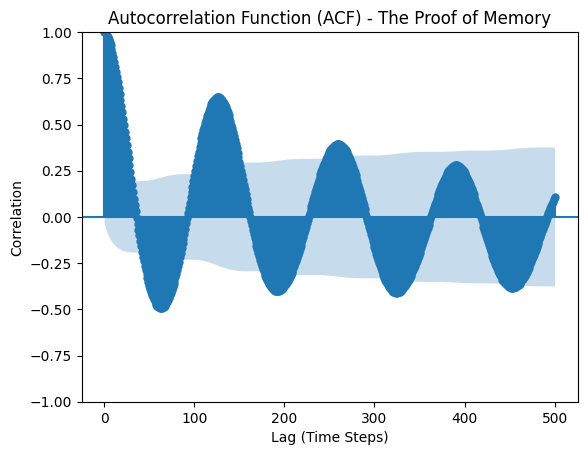

In [ ]:
plot_acf(output_df, lags=500, alpha=0.05)
plt.title("Autocorrelation Function (ACF) ")
plt.xlabel("Lag (Time Steps)")
plt.ylabel("Correlation")
plt.show()

### PACF


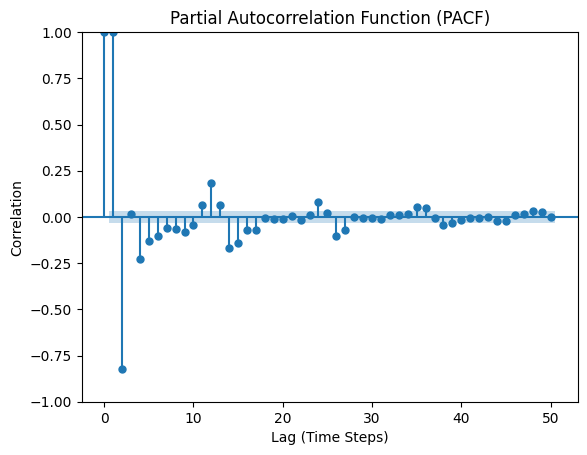

In [6]:
plot_pacf(output_df, lags=50)
plt.title("Partial Autocorrelation Function (PACF)")
plt.xlabel("Lag (Time Steps)")
plt.ylabel("Correlation")
plt.show()

## Hurst Exponent


Hurst Exponent (H): 0.7804


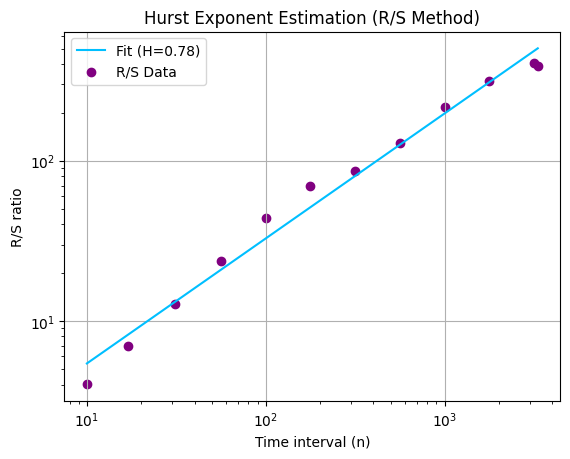

In [19]:
H, c, data = compute_Hc(output_df, kind="change", simplified=False)

print(f"Hurst Exponent (H): {H:.4f}")
f, ax = plt.subplots()
ax.plot(data[0], c * data[0] ** H, color="deepskyblue", label=f"Fit (H={H:.2f})")
ax.scatter(data[0], data[1], color="purple", label="R/S Data")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Time interval (n)")
ax.set_ylabel("R/S ratio")
ax.legend()
plt.title("Hurst Exponent Estimation (R/S Method)")
plt.grid(True)
plt.show()